In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.

In [ ]:
import lightgbm as lgb

2.

In [ ]:
estate_df1 = pd.read_csv('2_real_estate_valuation_1.csv')
estate_df2 = pd.read_csv('2_real_estate_valuation_2.csv')

estate_df = pd.merge(estate_df1, estate_df2, on='number', how='inner')

3.

In [ ]:
# 한글화를 위해 아래의 코드를 작성해 주세요.
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='area_sqm', ylabel='price_eok'>

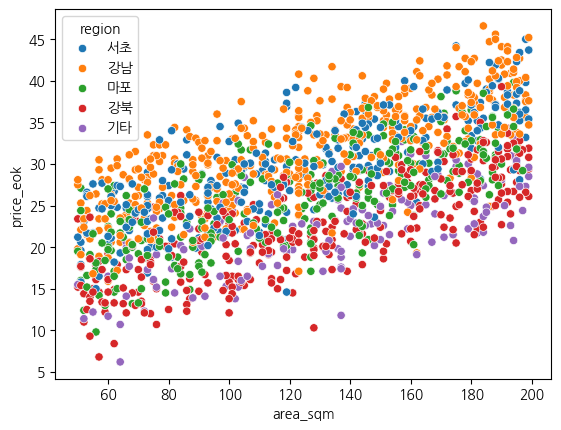

In [ ]:
sns.scatterplot(data=estate_df, x='area_sqm', y='price_eok', hue='region')

In [ ]:
답안03 = '3'

4.

<Axes: xlabel='building_material', ylabel='price_eok'>

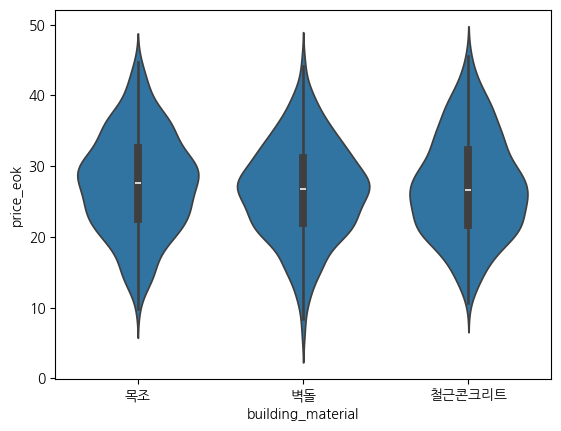

In [ ]:
sns.violinplot(data=estate_df, x='building_material', y='price_eok')

In [ ]:
q1 = estate_df[estate_df['building_material'] == '목조']['price_eok'].quantile(0.25)
q3 = estate_df[estate_df['building_material'] == '목조']['price_eok'].quantile(0.75)

IQR = q3 - q1
print(IQR)

답안04 = '10.05'

10.050000000000004


5.

In [ ]:
estate_df.groupby('region')[['subway_stations_1km', 'amenities_500m']].mean()

,subway_stations_1km,amenities_500m
region,,
강남,1.471132,7.112832
강북,1.387821,6.993769
기타,1.551471,6.666667
마포,1.475352,6.777397
서초,1.479021,7.070707


6.

In [ ]:
estate_pre = estate_df.copy()

estate_pre['num_rooms'].fillna(estate_pre['num_rooms'].median(), inplace=True)
estate_pre['num_bathrooms'].fillna(estate_pre['num_bathrooms'].median(), inplace=True)
estate_pre['building_age'].fillna(estate_pre['building_age'].median(), inplace=True)
estate_pre['parking_spaces'].fillna(estate_pre['parking_spaces'].median(), inplace=True)
estate_pre['subway_stations_1km'].fillna(estate_pre['subway_stations_1km'].median(), inplace=True)

estate_pre['building_material'].fillna('unknown', inplace=True)
estate_pre.drop(columns=['number'], inplace=True)

/tmp/ipykernel_2632/602445780.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  estate_pre['num_rooms'].fillna(estate_pre['num_rooms'].median(), inplace=True)
/tmp/ipykernel_2632/602445780.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

7.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

estate_pre['region'] = le.fit_transform(estate_pre['region'])
estate_pre['building_material'] = le.fit_transform(estate_pre['building_material'])

8.

In [ ]:
from sklearn.model_selection import train_test_split

X = estate_pre.drop(columns=['price_eok'])
y = estate_pre['price_eok']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

9.

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

10.

In [ ]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train_scaled, y_train)

ridge_pred = model_ridge.predict(X_valid_scaled)

11.

In [ ]:
# from lgb import LGBMRegressor

model_lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model_lgbm.fit(X_train_scaled, y_train)

lgbm_pred = model_lgbm.predict(X_valid_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 247
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] Start training from score 27.126667


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


12.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print('ridge')
print('mae', mean_absolute_error(y_valid, ridge_pred))
print('r2', r2_score(y_valid, ridge_pred))

print('lgbm')
print('mae', mean_absolute_error(y_valid, lgbm_pred))
print('r2', r2_score(y_valid, lgbm_pred))

ridge
mae 3.5348632350430913
r2 0.6506710529516206
lgbm
mae 1.167382251585949
r2 0.9240810312399343


13.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 25.1325 - val_loss: 21.0410
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.4689 - val_loss: 5.3780
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0465 - val_loss: 3.5306
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.4762 - val_loss: 3.2802
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0264 - val_loss: 3.1768
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0098 - val_loss: 3.0295
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.7031 - val_loss: 2.8073
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.6089 - val_loss: 2.6714
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5974 - val_loss: 2.6063
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3379 - val_loss: 2.4096
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1331 - val_loss: 2.3096
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - los

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_estate_data = np.array([[0, 120.0, 3.0, 2.0, 10.0, 1, 2.0, 2.0, 8.0, 9.0]])

In [ ]:
new_estate_data_scaled = ss.transform(new_estate_data)

predicted_price_dl = model.predict(new_estate_data_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
